In [92]:
using CMBLensing
using PythonPlot


Cℓ  = camb(r=0.05, ℓmax=21000)         
Cℓn = noiseCℓs(μKarcminT=1)  # removed ℓknee=100


θpix  = 0.7438046267475303  # pixel size in arcmin
Nside = 512      # number of pixels per side in the map
pol   = :I       # type of data to use (can be :T, :P, or :TP)
T     = Float32  # data type (Float32 is ~2 as fast as Float64);
bandpass_mask = LowPass(6000);

(;f, f̃, ϕ, ds) = load_sim(
    seed = 3,
    Cℓ = Cℓ,
    Cℓn = Cℓn,
    θpix = θpix,
    T = T,
    Nside = Nside,
    beamFWHM = 1.0,
    pol = pol,
    bandpass_mask = bandpass_mask, 
    pixel_mask_kwargs = (edge_padding_deg=0, apodization_deg=0, num_ptsrcs=0),
)



(f = ComplexF32[0.0f0 + 0.0f0im, -1.4355074f6 - 3.483249f6im, 3.2807038f6 - 4.531778f6im, -455595.7f0 + 120705.29f0im, -972343.9f0 + 297891.97f0im, 937233.5f0 + 1.9683731f6im, -106391.93f0 + 222771.42f0im, 379129.03f0 - 209760.14f0im, -269272.47f0 + 208467.47f0im, -43658.668f0 - 520942.03f0im  …  -2.9985697f0 + 1.7251345f0im, -10.190046f0 - 10.42925f0im, 0.3710811f0 + 3.7072842f0im, 5.331645f0 + 2.0137262f0im, -0.26298612f0 + 3.6719344f0im, 7.2763753f0 - 0.31616065f0im, -1.7443056f0 - 6.943406f0im, -11.064791f0 + 4.932134f0im, -5.0352793f0 + 7.488441f0im, 0.15712562f0 + 6.6466002f0im], f̃ = Float32[-149.3736, -147.7579, -145.56017, -143.00284, -140.87837, -139.30023, -138.73958, -138.59541, -138.75392, -138.56958  …  -87.92406, -99.09506, -109.467026, -118.06137, -124.803825, -130.9102, -136.25508, -139.98035, -142.26764, -143.0646], ϕ = ComplexF32[0.0f0 + 0.0f0im, 0.29005766f0 - 0.4476377f0im, 0.023752943f0 - 0.09520566f0im, 0.04078745f0 + 0.010236119f0im, -0.014798568f0 - 0.019218616

In [114]:
qe = quadratic_estimate(ds, Val(:TT), weights=:lensed, wiener_filtered=false)
ϕqe = qe.ϕqe


LoadError: AssertionError: which='Val{:TT}()' not implemented

In [ ]:
using CMBLensing: Map, Loess
Base.eval(CMBLensing, :(loess = Loess.loess))


Ωstart = FieldTuple(ϕ = qe.ϕqe)


result = MAP_joint(
    ds,
    Ωstart;
    nsteps = 20,
    nburnin_update_hessian = Inf,
    conjgrad_kwargs=(tol=1e-6, nsteps=100),
    progress=true
)



fJ = result.f
ϕJ = result.ϕ
hist = result.history

MAP_joint: 100%|████████████████████████████████████████| Time: 0:02:46
         step: 20
       logpdf: 6243437.00
            α: 0.018771691
     ΔΩ°_norm: 0.00047
           CG: 7 iterations (1.52 sec)
   Linesearch: 9 bisections (3.83 sec)


20-element Vector{Any}:
 (logpdf = 6.2425605f6,)
 (logpdf = 6.2426505f6,)
 (logpdf = 6.2427025f6,)
 (logpdf = 6.2427585f6,)
 (logpdf = 6.2428325f6,)
 (logpdf = 6.242903f6,)
 (logpdf = 6.242968f6,)
 (logpdf = 6.243032f6,)
 (logpdf = 6.243095f6,)
 (logpdf = 6.2431555f6,)
 (logpdf = 6.243189f6,)
 (logpdf = 6.2432185f6,)
 (logpdf = 6.243248f6,)
 (logpdf = 6.243281f6,)
 (logpdf = 6.2433095f6,)
 (logpdf = 6.243339f6,)
 (logpdf = 6.243371f6,)
 (logpdf = 6.243394f6,)
 (logpdf = 6.243415f6,)
 (logpdf = 6.243437f6,)

<sys>:0: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


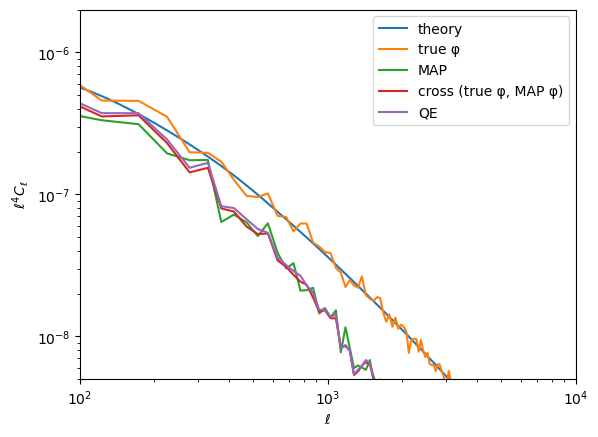

In [9]:
using CMBLensing: get_ρℓ, get_ℓ⁴Cℓ
# ------------------------------------------------------------------
# 5) Compare spectra
# ------------------------------------------------------------------
loglog(ℓ⁴ * Cℓ.total.ϕϕ,   label="theory")
loglog(get_ℓ⁴Cℓ(ϕ),         label="true φ")
loglog(get_ℓ⁴Cℓ(ϕJ),       label="MAP")
loglog(get_ℓ⁴Cℓ(ϕ, ϕJ),    label="cross (true φ, MAP φ)") 
loglog(get_ℓ⁴Cℓ(ϕ, quadratic_estimate(ds).ϕqe), label="QE") # QE reconstruction quality
xlim(100, 10000); ylim(5e-9, 2e-6); legend()
xlabel(raw"$\ell$")
ylabel(raw"$\ell^4 C_\ell$");
PythonPlot.show()





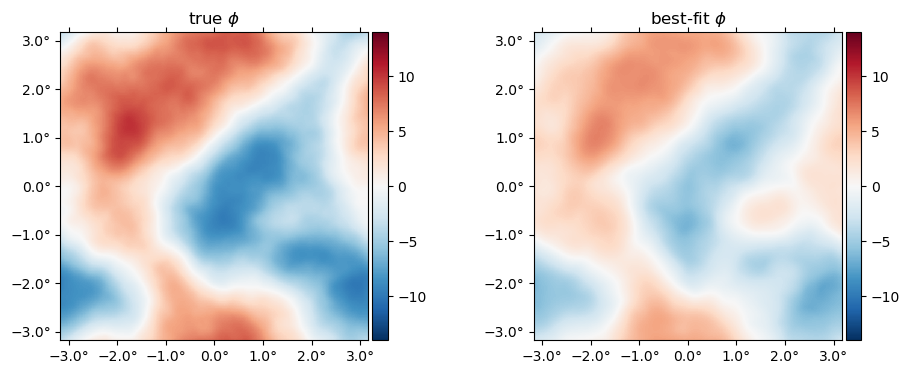

In [10]:
# ------------------------------------------------------------------
# 5) Lensing map visualisation
# ------------------------------------------------------------------
PythonPlot.plot(
    1e6 .* [ϕ  ϕJ],
    title = ["true" "best-fit"] .* raw" $\phi$",
    vlim = 14
)

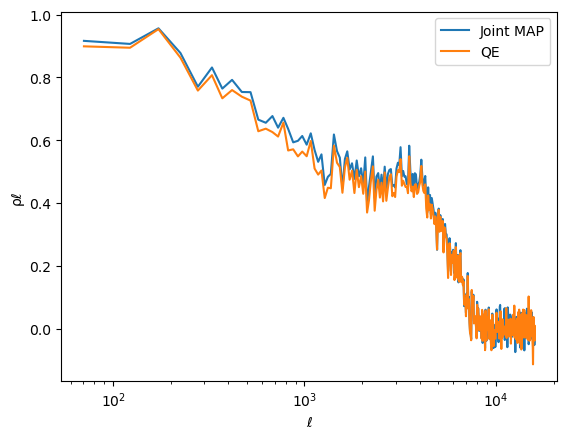

Python: <matplotlib.legend.Legend object at 0x34fe99590>

In [11]:
# ------------------------------------------------------------------
# 6) Correlation coefficient vs ell (ρℓ)
# ------------------------------------------------------------------

semilogx(get_ρℓ(ϕ, ϕJ))
semilogx(get_ρℓ(quadratic_estimate(ds).ϕqe, ϕ))
xlabel("ℓ")
ylabel("ρℓ")
legend(["Joint MAP", "QE"])

Creating FFT to get cross-correlation coefficients with adjustable binning

In [21]:
include("utils.jl")
using .Utils


In [22]:
# QE reconstruction


# True, MAP and QE spectra
C_true     = get_Cℓ_fft(ϕ)              # C_ℓ^{φφ}
C_map      = get_Cℓ_fft(ϕJ)             # C_ℓ^{φ̂_MAP φ̂_MAP}
C_qe       = get_Cℓ_fft(ϕqe)           # C_ℓ^{φ̂_QE  φ̂_QE}
C_crossMAP = get_Cℓ_fft(ϕ, ϕJ)          # C_ℓ^{φ φ̂_MAP}
C_crossQE  = get_Cℓ_fft(ϕ, ϕqe)        # C_ℓ^{φ φ̂_QE}

ℓ = C_crossMAP.ℓ              # all have the same ℓ grid

ρ_map = C_crossMAP.Cℓ ./ sqrt.(C_true.Cℓ .* C_map.Cℓ)
ρ_qe  = C_crossQE.Cℓ  ./ sqrt.(C_true.Cℓ .* C_qe.Cℓ)


300-element Vector{Float64}:
  0.9398913948349308
  0.8913845174718665
  0.9372356389825262
  0.865961462256465
  0.8226494555425391
  0.6318602442938295
  0.6896745256100127
  0.7652337300406092
  0.607261043068514
  0.6235781545232166
  0.6020077353255898
  0.6091300663954635
  0.610174189809356
  ⋮
 -0.07075427450235722
 -0.03142879933053703
  0.0005812015662244472
 -0.10586039075648261
 -0.2194255835667379
 -0.07818048502115407
 -0.049593279632241485
  0.040619251910950095
  0.19047839823053014
 -0.005119076110716629
  0.15404405179556624
  0.4000786056844082

Call MAP_Marg removing the set_distributed_dataset empty functions: 

- stores the dataset in a shared gloabl location so that multiple worker processes can access it without repeatedly shipping the full dataset across processes. 
- faster
- 

In [ ]:
using CMBLensing

# Add a module-private global inside CMBLensing to hold ds
@eval CMBLensing begin
    const _DIST_DS = Ref{Any}(nothing)

    set_distributed_dataset(x) = (_DIST_DS[] = x)
    get_distributed_dataset() = _DIST_DS[]
end




# --- MAP_marg call ---
ϕ_marg, hist_marg = MAP_marg(
    ds,
    ϕstart=ϕqe;
    nsteps = 15,
    nsteps_with_meanfield_update = 4,
    conjgrad_kwargs = (tol=1e-6,nsteps=500),
    progress = true,
    pmap = map
)


MAP_marg: 100%|█████████████████████████████████████████| Time: 0:09:08

(ComplexF32[0.0f0 + 0.0f0im, 0.061760556f0 - 0.29736137f0im, 0.06712235f0 - 0.12841186f0im, 0.043538813f0 + 0.016902426f0im, -0.021405784f0 - 0.010056866f0im, 0.009280689f0 + 0.00024476572f0im, -0.004780589f0 - 0.0013816688f0im, -0.0019868459f0 - 0.00053408125f0im, -0.0011020947f0 - 0.0030684015f0im, 0.000686232f0 + 0.0007917098f0im  …  4.1485867f-11 - 1.30332f-10im, 7.517206f-11 + 1.0173556f-11im, -5.005314f-11 + 5.6527432f-11im, 1.4888178f-10 - 6.3414086f-11im, 1.2661122f-11 + 1.0562445f-11im, 5.110493f-11 - 6.19144f-11im, 5.7708664f-12 + 4.8679637f-11im, -4.8323526f-11 + 7.129452f-11im, -4.778227f-11 + 4.4759986f-12im, 2.6127201f-11 - 1.0971509f-11im], Any[(step = 1, g = ComplexF32[0.0f0 + 0.0f0im, -172630.33f0 - 493419.5f0im, 406252.0f0 + 176653.38f0im, 5.746663f6 + 3.3348635f6im, -4.035326f6 + 7.008309f6im, -5.739489f6 - 2.5971116f7im, -1.3928447f7 + 7.262798f6im, -2.1586016f7 - 5.1456584f7im, 6.550842f6 + 6.859915f7im, 5.4046092f7 + 6.9548936f7im  …  -2.4513142f9 + 7.0093414f9im,


        step: 15
           α: 0.2
   CG (data): 7 iterations


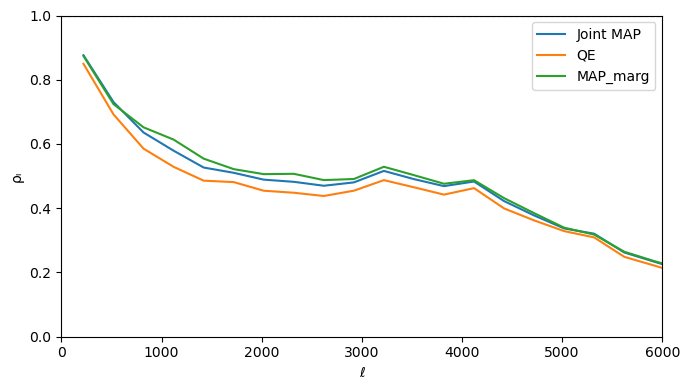

In [109]:
# --- Compute correlations ---
ρ_map  = get_ρℓ(ϕ,      ϕJ)
ρ_qe   = get_ρℓ(ϕqe, ϕ)
ρ_marg = get_ρℓ(ϕ_marg, ϕ)          # ← NEW LINE

# --- Bin for smoothing ---
ΔL = 300       
Lmap,  ρmap_b  = bin_spectrum(ρ_map.ℓ,  ρ_map.Cℓ;  ΔL=ΔL)
Lqe,   ρqe_b   = bin_spectrum(ρ_qe.ℓ,   ρ_qe.Cℓ;   ΔL=ΔL)
Lmarg, ρmarg_b = bin_spectrum(ρ_marg.ℓ, ρ_marg.Cℓ; ΔL=ΔL)   # ← NEW LINE

# --- Plot (linear x-axis) ---
using PythonPlot
plt = PythonPlot
plt.figure(figsize=(7,4))

plt.plot(Lmap,  ρmap_b,  label="Joint MAP")
plt.plot(Lqe,   ρqe_b,   label="QE")
plt.plot(Lmarg, ρmarg_b, label="MAP_marg")     # ← NEW LINE

plt.axhline(1, color="k", linestyle="--", linewidth=0.8)

plt.xlim(0, 6000)      # match Louis’ plots
plt.ylim(0, 1)

plt.xlabel("ℓ")
plt.ylabel("ρₗ")
plt.legend()
plt.tight_layout()
plt.show()
# savefig("correlation_coefficient_bandpass_4000.png", dpi=300)


Save file data for bandpass

Exploring gradient correlation with error

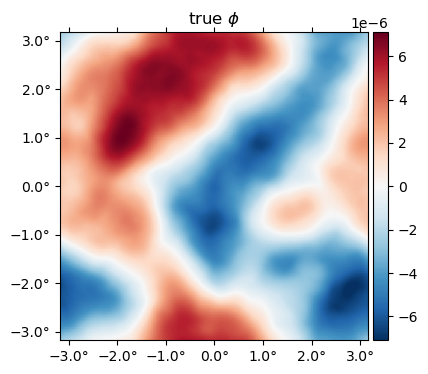

In [106]:
plot(ϕJ, title = raw"true $\phi$");

In [26]:
using FFTW
using CMBLensing: m_rfft, m_irfft, Map
using Statistics

"""
    grad_fft(T)

Compute gradient (∂T/∂x, ∂T/∂y) **per radian** using FFT.
"""
function grad_fft(T)

    m = Map(T)
    proj = m.proj
    Ny, Nx = size(m.arr)
    g = m.arr
    
    θpix_rad = θpix * (π / 180) / 60  # pixel size in radians
    # --- FFT of the temperature map ---
    F = m_rfft(g, (1,2))     # NyF × NxF
    NyF, NxF = size(F)

    # --- ℓ grid ---
    ℓx = proj.ℓx[1:NxF]          # length NxF
    ℓy = proj.ℓy[1:NyF]          # length NyF

    ℓx2D = repeat(ℓx', NyF, 1)
    ℓy2D = repeat(ℓy , 1, NxF)

    # --- Fourier–space derivatives ---
    dTdx_F = (im .* ℓx2D) .* F
    dTdy_F = (im .* ℓy2D) .* F

    # --- Inverse FFT (real space) ---
    dTdx = m_irfft(dTdx_F, Ny, (1,2)) * θpix_rad
    dTdy = m_irfft(dTdy_F, Ny, (1,2)) * θpix_rad


    grad_mag = sqrt.(dTdx.^2 .+ dTdy.^2)

    return dTdx, dTdy, grad_mag
end


function plot_grad_T_lensed(f̃)
    dTdx, dTdy, grad_mag = grad_fft(f̃)

    lo = quantile(vec(grad_mag), 0.2)
    hi = quantile(vec(grad_mag), 0.8)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(dTdx, cmap="RdBu_r", vmin=lo, vmax=hi)
    plt.title("∂T/∂x  (µK per pixel)")
    plt.colorbar()

    plt.subplot(1,3,2)
    plt.imshow(dTdy, cmap="RdBu_r", vmin=lo, vmax=hi)
    plt.title("∂T/∂y  (µK per pixel)")
    plt.colorbar()

    plt.subplot(1,3,3)
    plt.imshow(grad_mag, cmap="viridis", vmin=lo, vmax=hi)
    plt.title("|∇T|  (µK per pixel)")
    plt.colorbar()

    plt.tight_layout()
end


plot_grad_T_lensed (generic function with 1 method)

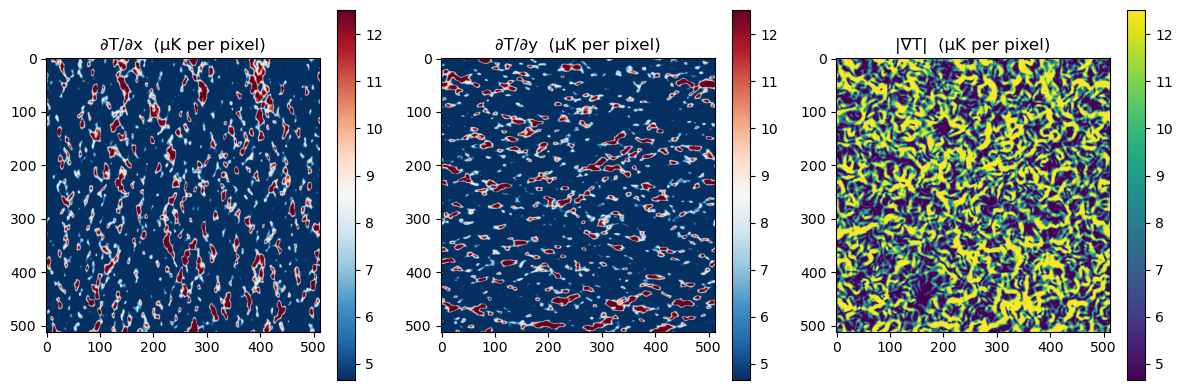

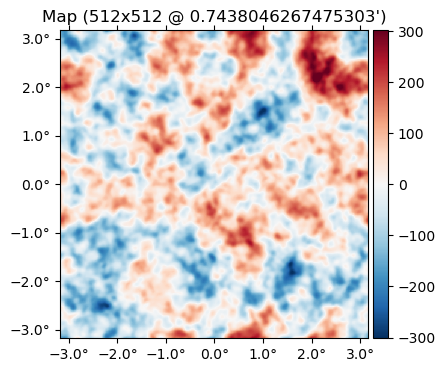

In [84]:
plot_grad_T_lensed(f̃)
plot(f̃)


In [28]:
function compare_gradT_phi_errors(f̃, ϕ, ϕJ, ϕmarg, ϕqe)
    # 1. Compute |∇T|
    _, _, gradT = grad_fft(f̃)
    gradT = gradT ./ maximum(gradT)   # normalise 0–1 for better contrast

    # 2. φ residuals in μK
    Δϕ_QE   = Map(ϕ .- ϕqe).arr
    Δϕ_J    = Map(ϕ .- ϕJ).arr
    Δϕ_marg = Map(ϕ .- ϕmarg).arr
    Δϕ_test   = Map(ϕ).arr
    scale = 1e6
    dQE   = scale .* (Δϕ_QE)
    dJ    = scale .* (Δϕ_J)
    dMarg = scale .* (Δϕ_marg)
    dtest = scale .* (Δϕ_test)




    # symmetric φ error scale
    m = maximum(abs.([dQE; dJ; dMarg]))
    lo, hi = -m, m

    plt.figure(figsize=(14,7))

    # |∇T|
    plt.subplot(2,3,1)
    plt.imshow(gradT, cmap="inferno")
    plt.title("|∇T| (normalised)")
    plt.colorbar()

    # φ residuals
    plt.subplot(2,3,2)
    plt.imshow(dQE, cmap="RdBu_r", vmin=lo, vmax=hi)
    plt.title("φ_true − φ_QE")
    plt.colorbar()

    plt.subplot(2,3,3)
    plt.imshow(dJ, cmap="RdBu_r", vmin=lo, vmax=hi)
    plt.title("φ_true − φ_joint")
    plt.colorbar()

    plt.subplot(2,3,4)
    plt.imshow(dMarg, cmap="RdBu_r", vmin=lo, vmax=hi)
    plt.title("φ_true − φ_marg")
    plt.colorbar()

    plt.subplot(2,3,5)
    plt.imshow(dtest, cmap="RdBu_r", vmin=lo, vmax=hi)
    plt.title("φ_true")
    plt.colorbar()

    plt.tight_layout()
end


compare_gradT_phi_errors (generic function with 1 method)

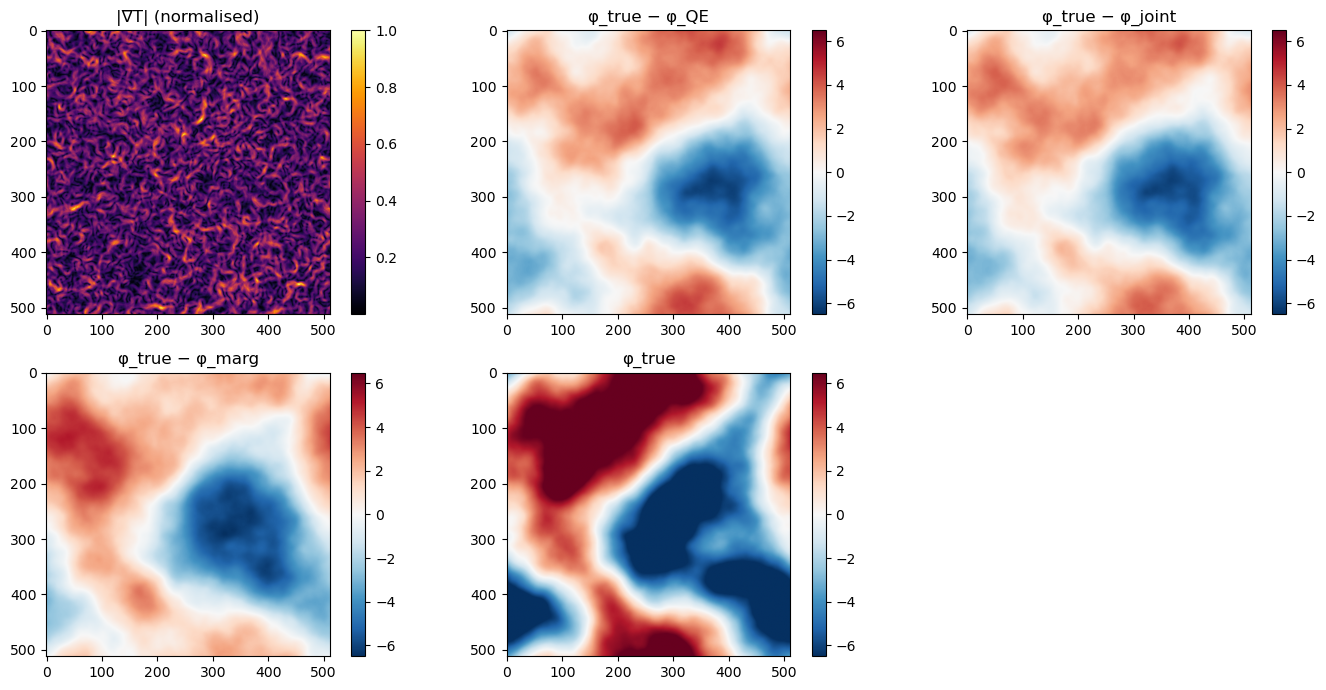

Python: None

In [29]:
compare_gradT_phi_errors(f̃, ϕ, ϕJ, ϕ_marg, ϕqe)

In [74]:
using Statistics
ϕ_QE = quadratic_estimate(ds, :TT; wiener_filtered=false).ϕqe

Δϕ_QE   = 1e6 .*abs.(Map(ϕ .- ϕ_QE).arr)
Δϕ_J    = 1e6 .*abs.(Map(ϕ .- ϕJ).arr)
Δϕ_marg = 1e6 .*abs.(Map(ϕ .- ϕ_marg).arr)
σ_QE = std(vec(Δϕ_QE))
@show mean(vec(Δϕ_QE)), σ_QE



(mean(vec(Δϕ_QE)), σ_QE) = (3.9534626034108538, 3.102559288497349)


(3.9534626034108538, 3.102559288497349)

In [31]:
using CMBLensing
using FFTW
using Statistics

# Compute binned spectra
function cross_spectrum(f1, f2, proj; nbins=50)
    ϕ1 = Fourier(Map(f1)).arr
    ϕ2 = Fourier(Map(f2)).arr

    ℓ2 = proj.ℓmag.^2       # array of ℓ² per Fourier mode
    ℓ = sqrt.(ℓ2)

    # define bins
    ℓmax = maximum(ℓ)
    edges = range(0, ℓmax; length=nbins+1)
    num = zeros(nbins)
    den = zeros(nbins)

    for i in eachindex(ℓ)
        L = ℓ[i]
        b = searchsortedfirst(edges, L) - 1
        if b < 1 || b > nbins; continue; end
        num[b] += real(ϕ1[i] * conj(ϕ2[i]))
        den[b] += 1
    end

    return num ./ (den .+ 1e-12), edges
end


cross_spectrum (generic function with 1 method)

In [32]:
# reconstruct a single simulation and return (ϕ_rec, ϕ_true)
function reconstruct_one_sim(rng, ds; method=:QE)
    # 1. generate simulation with known φ_true
    sim = simulate(rng, ds)
    ϕ_true = Map(sim.ϕ)

    # 2. reconstruct
    if method == :QE
        out = quadratic_estimate(ds; wiener_filtered=false)
        ϕ_rec = out.ϕqe

    elseif method == :joint
        (_, ϕ_map, _) = MAP_joint(ds; nsteps=12, progress=false)
        ϕ_rec = ϕ_map

    elseif method == :marg
        (ϕ_map, _) = MAP_marg(ds; nsteps=8, progress=false)
        ϕ_rec = ϕ_map

    else
        error("unknown method $method")
    end

    return ϕ_rec, ϕ_true
end


reconstruct_one_sim (generic function with 1 method)

In [33]:
using Random

function compute_RL(ds; method=:QE, Nsims=20, nbins=50)
    rng = Random.default_rng()

    # accumulators
    num_acc = zeros(nbins)
    den_acc = zeros(nbins)
    edges = nothing

    for i in 1:Nsims
        println("Sim $i / $Nsims for method = $method")

        ϕ_rec, ϕ_true = reconstruct_one_sim(rng, ds; method)

        # cross-spectrum <ϕ_rec ϕ_true*>
        num, edges = cross_spectrum(ϕ_rec, ϕ_true, ds.d.proj; nbins=nbins)

        # auto-spectrum of true φ
        den, _ = cross_spectrum(ϕ_true, ϕ_true, ds.d.proj; nbins=nbins)

        num_acc .+= num
        den_acc .+= den
    end

    RL = num_acc ./ (den_acc .+ 1e-12)
    return RL, edges
end


compute_RL (generic function with 1 method)

In [34]:
RL_QE, bins   = compute_RL(ds; method=:QE,    Nsims=10)
RL_J,  bins   = compute_RL(ds; method=:joint, Nsims=10)
RL_M,  bins   = compute_RL(ds; method=:marg,  Nsims=10)


Sim 1 / 10 for method = QE
Sim 2 / 10 for method = QE
Sim 3 / 10 for method = QE
Sim 4 / 10 for method = QE
Sim 5 / 10 for method = QE
Sim 6 / 10 for method = QE
Sim 7 / 10 for method = QE
Sim 8 / 10 for method = QE
Sim 9 / 10 for method = QE
Sim 10 / 10 for method = QE
Sim 1 / 10 for method = joint
Sim 2 / 10 for method = joint
Sim 3 / 10 for method = joint
Sim 4 / 10 for method = joint
Sim 5 / 10 for method = joint
Sim 6 / 10 for method = joint
Sim 7 / 10 for method = joint
Sim 8 / 10 for method = joint
Sim 9 / 10 for method = joint
Sim 10 / 10 for method = joint
Sim 1 / 10 for method = marg
Sim 2 / 10 for method = marg
Sim 3 / 10 for method = marg
Sim 4 / 10 for method = marg
Sim 5 / 10 for method = marg
Sim 6 / 10 for method = marg
Sim 7 / 10 for method = marg
Sim 8 / 10 for method = marg
Sim 9 / 10 for method = marg
Sim 10 / 10 for method = marg


([-0.007045526903559694, -0.009832037833935188, 0.002703412524815503, 0.00227818000032601, -0.00583389407366234, -0.0005819283200252342, 0.0014532729192120656, -0.0017874021865412232, -0.00011143934505651673, -0.0025510728067525378  …  7.432029092653059e-8, -1.5894373799853842e-7, -2.2629618278523732e-7, 2.846050191064533e-7, -1.3709032954051633e-8, 5.446986584615082e-7, -7.707480243197812e-9, -4.429128384252243e-7, 1.2448824440007405e-6, -1.191451209440837e-6], 0.0f0:410.68597f0:20534.299f0)

In [79]:
ϕ_qe_debiased = ϕqe/RL_QE
ϕ_J_debiased  = ϕJ/RL_J
ϕ_M_debiased  = ϕ_marg/RL_M

131584×50 Matrix{ComplexF64}:
         -0.0-0.0im          …          -0.0-0.0im
     -3.29168+7.35521im         -0.000556648+0.00124382im
     -1.89812+3.64891im         -0.000320987+0.000617059im
     -1.02155-0.39686im         -0.000172752-6.7112e-5im
     0.541434+0.273512im          9.15606e-5+4.62529e-5im
     -0.17526-0.0305315im    …   -2.96378e-5-5.1631e-6im
     0.131987+0.0284218im           2.232e-5+4.80634e-6im
    0.0249308+0.00809376im        4.21598e-6+1.36872e-6im
    0.0421401+0.0775948im         7.12621e-6+1.31219e-5im
   -0.0207229-0.0239023im         -3.5044e-6-4.04206e-6im
   -0.0574566+0.0312617im    …   -9.71634e-6+5.28658e-6im
   -0.0207386+0.0333187im        -3.50704e-6+5.63443e-6im
     0.012576+0.0434585im          2.1267e-6+7.34915e-6im
             ⋮               ⋱  
  8.82561e-11-1.37864e-11im      1.49248e-14-2.33138e-15im
  5.96192e-11-7.15763e-11im      1.00821e-14-1.21041e-14im
  4.50106e-11+6.12811e-11im      7.61162e-15+1.03631e-14im
   1.4982e-10+

In [ ]:
using CMBLensing: Map, BaseField, m_rfft, m_irfft, Fourier, ProjLambert

function debias_phi(ϕ_rec, RL, bins, proj)

    # ----- 1. Convert φ_rec → Fourier-φ --------------------------------
    if ϕ_rec isa Map
        φ_real = ϕ_rec.arr
        Ny, Nx = size(φ_real)
        φF = m_rfft(φ_real, (1,2))

    elseif ϕ_rec isa BaseField{Fourier}
        φF = ϕ_rec.arr
        Ny = proj.Ny

    else
        error("Unknown φ type: $(typeof(ϕ_rec))")
    end

    # ----- 2. Debias φF -------------------------------------------------
    ℓ = proj.ℓmag
    debiasF = similar(φF)

    for idx in eachindex(φF)
        L = ℓ[idx]
        b = searchsortedfirst(bins, L) - 1
        debiasF[idx] = (1 ≤ b ≤ length(RL)) ? φF[idx] / RL[b] : zero(eltype(φF))
    end

    # ----- 3. Convert back to REAL SPACE -------------------
    φ_arr = m_irfft(debiasF, Ny, (1,2))

    # Correct real-space BaseField
    φ_field = BaseField{Map}(φ_arr, proj)

    # Wrap in a Map
    return Map(φ_field)
end


debias_phi (generic function with 1 method)

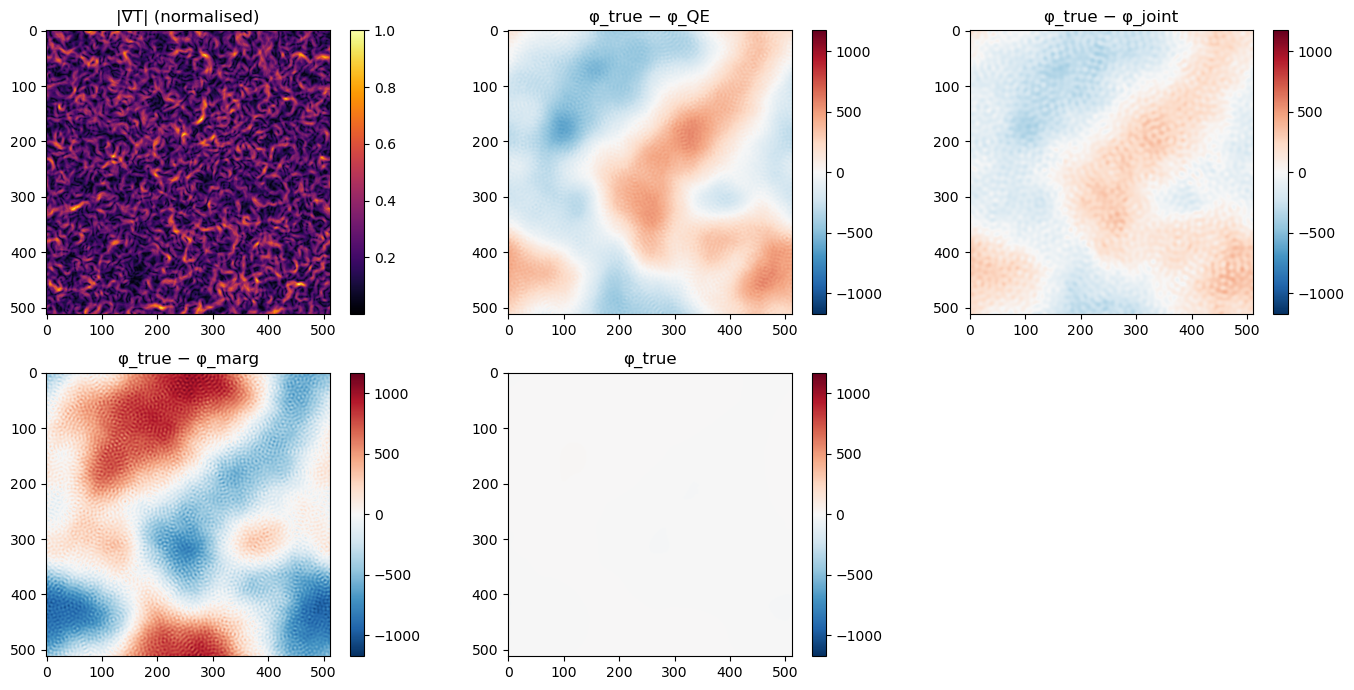

Python: None

In [ ]:
# true φ from load_sim (Fourier basis)
ϕ_true_fourier = ϕ

# convert true φ to Map basis
ϕ_true_map = Map(ϕ_true_fourier)

# unbiased reconstructions (already Map basis from debias_phi)
ϕ_QE_unbiased    = debias_phi(ϕ_QE,   RL_QE, bins, ds.d.proj)
ϕ_Joint_unbiased = debias_phi(ϕJ,   RL_J,  bins, ds.d.proj)
ϕ_Marg_unbiased  = debias_phi(ϕ_marg,   RL_M,  bins, ds.d.proj)

# All φ’s passed to these functions are Map-basis BaseFields
compare_gradT_phi_errors(f̃, ϕ_true_map, ϕ_Joint_unbiased, ϕ_Marg_unbiased, ϕ_QE_unbiased)


In [85]:
using Statistics
using PythonPlot

"""
    bin_stat(x, y; nbins=20)

Given two same-size arrays x,y:
- bins x into `nbins` equal-width bins
- returns (bin_centres, mean(y) in each bin)
"""
function bin_stat(x, y; nbins=20)
    xvec = vec(x)
    yvec = vec(y)

    lo, hi = minimum(xvec), maximum(xvec)
    edges = range(lo, hi; length=nbins+1)

    means = Float64[]
    centres = Float64[]

    for i in 1:nbins
        binmask = (edges[i] .<= xvec .< edges[i+1])
        push!(centres, 0.5*(edges[i] + edges[i+1]))

        if any(binmask)
            push!(means, mean(yvec[binmask]))
        else
            push!(means, NaN)
        end
    end
    return centres, means
end


"""
    plot_phi_error_vs_gradT(f̃, Δϕ_QE, Δϕ_J, Δϕ_marg)

Plots mean |Δϕ| vs |∇T| per-pixel for each estimator.
"""
function plot_phi_error_vs_gradT(f̃, Δϕ_QE, Δϕ_J, Δϕ_marg)
    # gradient magnitude per pixel (µK per pixel)
    _, _, grad_mag = grad_fft(f̃)          # |∇T| per rad
    grad_pix = grad_mag .* (π/180/60)      # convert per rad → per arcmin (pixel unit)
                                           
    # absolute φ errors
    e_QE   = abs.(Δϕ_QE)
    e_J    = abs.(Δϕ_J)
    e_marg = abs.(Δϕ_marg)

    # binning
    cen, m_QE   = bin_stat(grad_pix, e_QE)
    _,   m_J    = bin_stat(grad_pix, e_J)
    _,   m_marg = bin_stat(grad_pix, e_marg)

    # plot
    plt.figure(figsize=(7,5))
    plt.plot(cen, m_QE,   label="QE",       marker="o")
    plt.plot(cen, m_J,    label="Joint MAP", marker="s")
    plt.plot(cen, m_marg, label="MAP_marg",  marker="^")
    plt.xlabel("|∇T|  (µK per pixel)")
    plt.ylabel("mean |Δϕ|")
    plt.title("Mean |Δϕ| vs |∇T|")
    plt.grid(true, alpha=0.3)
    plt.legend()
    plt.tight_layout()
end


plot_phi_error_vs_gradT

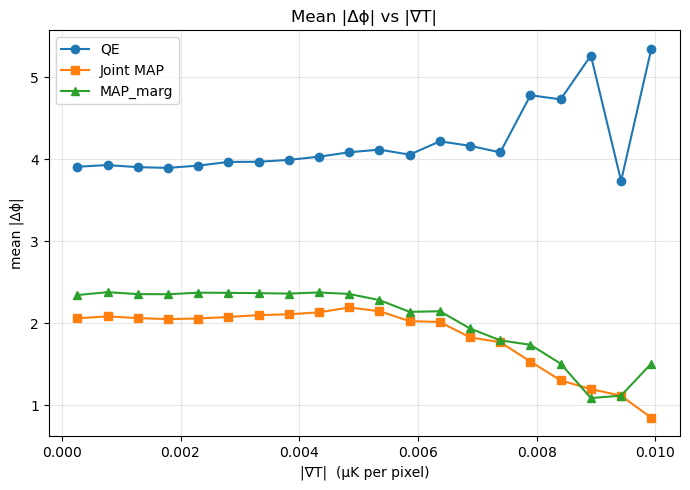

Python: None

In [86]:
plot_phi_error_vs_gradT(f̃, Δϕ_QE, Δϕ_J, Δϕ_marg)


In [77]:
using Statistics
dTdx, dTdy, grad_mag = grad_fft(f̃)


corr_QE   = cor(vec(grad_mag), vec(abs.(Δϕ_QE)))
corr_J    = cor(vec(grad_mag), vec(abs.(Δϕ_J)))
corr_marg = cor(vec(grad_mag), vec(abs.(Δϕ_marg)))

@show corr_QE corr_J corr_marg



corr_QE = 0.019129686138813985
corr_J = 0.006937185633454814
corr_marg = -0.017120758616507855


-0.017120758616507855

In [ ]:
using PythonPlot

function scatter_grad_vs_phi(gradT, Δϕ, label)
    plt.figure(figsize=(6,5))
    plt.scatter(vec(gradT), vec(Δϕ), s=0.2, alpha=0.1)
    plt.xlabel("|∇T| (μK per pixel, smoothed)")
    plt.ylabel("|φ_true − φ_rec| × 1e6")
    plt.title(label)
    plt.grid(true)
end


In [ ]:
scatter_grad_vs_phi(grad_mag, Δϕ_QE,  "QE")
scatter_grad_vs_phi(grad_mag, Δϕ_J,   "Joint")
scatter_grad_vs_phi(grad_mag, Δϕ_marg,"Marginal")
